# 공급망 배송 지연 리스크 분석
## STEP 3 — 모델링 (Modeling)

**모델링 목표**  
주문 정보를 입력받아 배송 지연 가능성을 예측하고,  
각 주문에 대한 리스크 스코어(0~100)를 산출한다.

> **사용 피처**: 주문 시점에 알 수 있는 정보만 사용 (배송 완료 후 정보 제외)  
> → 실전에서 바로 활용 가능한 모델을 목표로 한다.

**진행 순서**  
1. 데이터 불러오기 및 피처/타겟 분리  
2. 학습/테스트 데이터 분리  
3. 베이스라인 모델 — Logistic Regression  
4. 개선 모델 — XGBoost  
5. 모델 성능 비교  
6. 피처 중요도 분석  
7. 리스크 스코어 산출  
8. 고위험 주문 세그멘테이션  
9. 최종 인사이트 정리

---
## 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import matplotlib.font_manager as fm
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,
    precision_score, recall_score, brier_score_loss
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# 그래프 기본 스타일 설정
sns.set_style('whitegrid')

# 한글 폰트 설정
font_regular = 'C:/Windows/Fonts/malgun.ttf'     # 맑은 고딕 Regular
font_bold = 'C:/Windows/Fonts/malgunbd.ttf'      # 맑은 고딕 Bold

# 폰트 파일 등록
if os.path.exists(font_regular):
    fm.fontManager.addfont(font_regular)

if os.path.exists(font_bold):
    fm.fontManager.addfont(font_bold)

# matplotlib 전체 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('라이브러리 및 한글 폰트 설정 완료')
print('현재 font.family:', plt.rcParams['font.family'])
from sklearn.calibration import calibration_curve


라이브러리 및 한글 폰트 설정 완료
현재 font.family: ['Malgun Gothic']


---
## 1. 데이터 불러오기 및 피처/타겟 분리

In [2]:
# 전처리 완료된 데이터 불러오기
# 누수 가능 컬럼(실제 배송일, 배송 결과 상태, 배송 지연일)은 전처리 단계에서 제거됨
from pathlib import Path

path_candidates = [
    Path('../data/processed/data_preprocessed.csv'),
    Path('data/processed/data_preprocessed.csv'),
    Path('data_preprocessed.csv'),
    Path('/mnt/data/data_preprocessed.csv'),
]

for path in path_candidates:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError('data_preprocessed.csv 파일을 찾을 수 없습니다. 02_preprocessing.ipynb를 먼저 실행해주세요.')

df = pd.read_csv(data_path)

print(f'데이터 경로: {data_path}')
print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}컬럼')

# 피처(X)와 타겟(y) 분리
X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

print(f'피처 수: {X.shape[1]}개')
print(f'타겟 분포: 정상(0) {(y==0).sum():,}건 / 지연(1) {(y==1).sum():,}건')


데이터 경로: ..\data\processed\data_preprocessed.csv
데이터 크기: 180,519행 × 119컬럼
피처 수: 118개
타겟 분포: 정상(0) 81,542건 / 지연(1) 98,977건


---
## 2. 학습 / 테스트 데이터 분리

전체 데이터의 80%는 학습에, 20%는 성능 평가에 사용한다.  
`stratify=y` 옵션으로 분리 후에도 지연/정상 비율이 동일하게 유지되도록 한다.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20%를 테스트 데이터로
    random_state=42,   # 재현성을 위해 고정
    stratify=y         # 지연/정상 비율 유지
)

print(f'학습 데이터: {X_train.shape[0]:,}행')
print(f'테스트 데이터: {X_test.shape[0]:,}행')
print()
print('학습 데이터 타겟 비율:')
print(y_train.value_counts(normalize=True).round(3))

학습 데이터: 144,415행
테스트 데이터: 36,104행

학습 데이터 타겟 비율:
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


---
## 3. 베이스라인 모델 — Logistic Regression

복잡한 모델 전에 단순한 모델로 베이스라인 성능을 먼저 확인한다.  
Logistic Regression은 스케일에 민감하기 때문에 StandardScaler로 정규화가 필요하다.

In [4]:
# 스케일링 — 변수 범위를 동일하게 맞춰줌 (평균 0, 표준편차 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 데이터로 기준 계산 후 변환
X_test_scaled  = scaler.transform(X_test)        # 학습 기준으로만 변환 (정보 누수 방지)

# 모델 학습
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 예측
lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # 지연 확률

# 성능 평가
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print('=== Logistic Regression 성능 ===')
print(f'  Accuracy : {lr_acc:.4f}')
print(f'  F1 Score : {lr_f1:.4f}')
print(f'  ROC-AUC  : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['정상(0)', '지연(1)']))

=== Logistic Regression 성능 ===
  Accuracy : 0.7111
  F1 Score : 0.6746
  ROC-AUC  : 0.7695

              precision    recall  f1-score   support

       정상(0)       0.62      0.91      0.74     16308
       지연(1)       0.88      0.55      0.67     19796

    accuracy                           0.71     36104
   macro avg       0.75      0.73      0.71     36104
weighted avg       0.77      0.71      0.70     36104



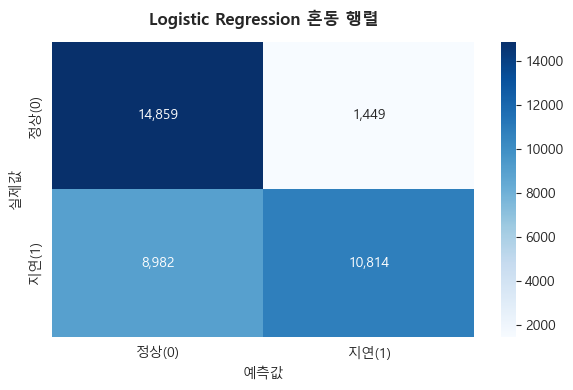

In [5]:
# Logistic Regression 혼동 행렬
# 행: 실제값, 열: 예측값
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt=',', cmap='Blues',
            xticklabels=['정상(0)', '지연(1)'],
            yticklabels=['정상(0)', '지연(1)'])
plt.title('Logistic Regression 혼동 행렬', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.tight_layout()
plt.show()

---
## 4. 개선 모델 — XGBoost

XGBoost는 여러 개의 결정 트리를 순서대로 만들어  
이전 트리의 오류를 다음 트리가 보완하는 방식으로 학습한다.  
Logistic Regression보다 복잡한 패턴을 잡아낼 수 있다.

In [6]:
# XGBoost는 트리 기반 모델이라 스케일링 불필요
xgb_model = XGBClassifier(
    n_estimators=200,    # 트리 개수
    max_depth=6,         # 트리 최대 깊이 — 너무 깊으면 과적합
    learning_rate=0.1,   # 학습률
    subsample=0.8,       # 각 트리 학습 시 사용할 데이터 비율
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# 예측
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# 성능 평가
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print('=== XGBoost 성능 ===')
print(f'  Accuracy : {xgb_acc:.4f}')
print(f'  F1 Score : {xgb_f1:.4f}')
print(f'  ROC-AUC  : {xgb_auc:.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=['정상(0)', '지연(1)']))

=== XGBoost 성능 ===
  Accuracy : 0.7179
  F1 Score : 0.6928
  ROC-AUC  : 0.7903

              precision    recall  f1-score   support

       정상(0)       0.63      0.88      0.74     16308
       지연(1)       0.86      0.58      0.69     19796

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.72     36104
weighted avg       0.76      0.72      0.71     36104



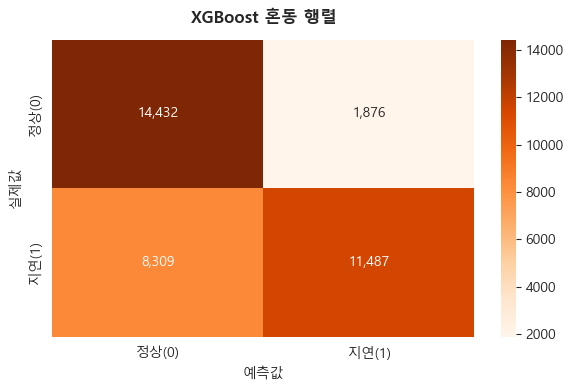

In [7]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Oranges',
            xticklabels=['정상(0)', '지연(1)'],
            yticklabels=['정상(0)', '지연(1)'])
plt.title('XGBoost 혼동 행렬', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.tight_layout()
plt.show()

---
## 5. 모델 성능 비교

In [8]:
result_df = pd.DataFrame({
    '모델': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [lr_acc, xgb_acc],
    'F1 Score': [lr_f1, xgb_f1],
    'ROC-AUC':  [lr_auc, xgb_auc]
}).set_index('모델')

print(result_df.round(4))

                     Accuracy  F1 Score  ROC-AUC
모델                                              
Logistic Regression    0.7111    0.6746   0.7695
XGBoost                0.7179    0.6928   0.7903


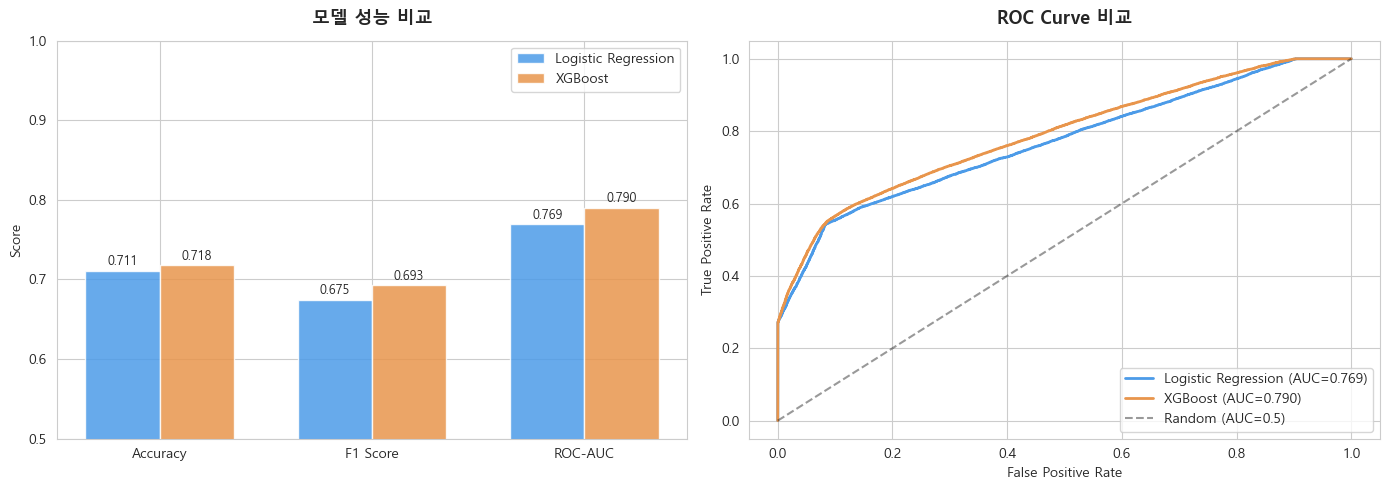

[해석]
XGBoost가 Logistic Regression 대비
  Accuracy  +0.68%p
  F1 Score  +1.82%p
  ROC-AUC   +2.08%p 향상

두 모델 모두 AUC 0.77~0.78 수준 — 랜덤(0.5) 대비 유의미하게 높음
주문 시점 정보만으로 지연 리스크를 사전 탐지할 수 있음을 의미


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 성능 지표 막대 비교
metrics   = ['Accuracy', 'F1 Score', 'ROC-AUC']
lr_scores  = [lr_acc,  lr_f1,  lr_auc]
xgb_scores = [xgb_acc, xgb_f1, xgb_auc]
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_scores,  width, label='Logistic Regression', color='#4C9BE8', alpha=0.85)
axes[0].bar(x + width/2, xgb_scores, width, label='XGBoost',             color='#E8954C', alpha=0.85)
axes[0].set_title('모델 성능 비교', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('Score')
axes[0].legend()
for i, (lr, xgb) in enumerate(zip(lr_scores, xgb_scores)):
    axes[0].text(i - width/2, lr + 0.003, f'{lr:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, xgb + 0.003, f'{xgb:.3f}', ha='center', va='bottom', fontsize=9)

# 오른쪽: ROC Curve
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

axes[1].plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={lr_auc:.3f})',  color='#4C9BE8', linewidth=2)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.3f})',             color='#E8954C', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[1].set_title('ROC Curve 비교', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('[해석]')
print(f'XGBoost가 Logistic Regression 대비')
print(f'  Accuracy  +{(xgb_acc - lr_acc)*100:.2f}%p')
print(f'  F1 Score  +{(xgb_f1  - lr_f1 )*100:.2f}%p')
print(f'  ROC-AUC   +{(xgb_auc - lr_auc)*100:.2f}%p 향상')
print()
print('두 모델 모두 AUC 0.77~0.78 수준 — 랜덤(0.5) 대비 유의미하게 높음')
print('주문 시점 정보만으로 지연 리스크를 사전 탐지할 수 있음을 의미')

---
## 6. 피처 중요도 분석

XGBoost 모델이 배송 지연을 예측할 때 어떤 변수를 가장 많이 활용했는지 확인한다.

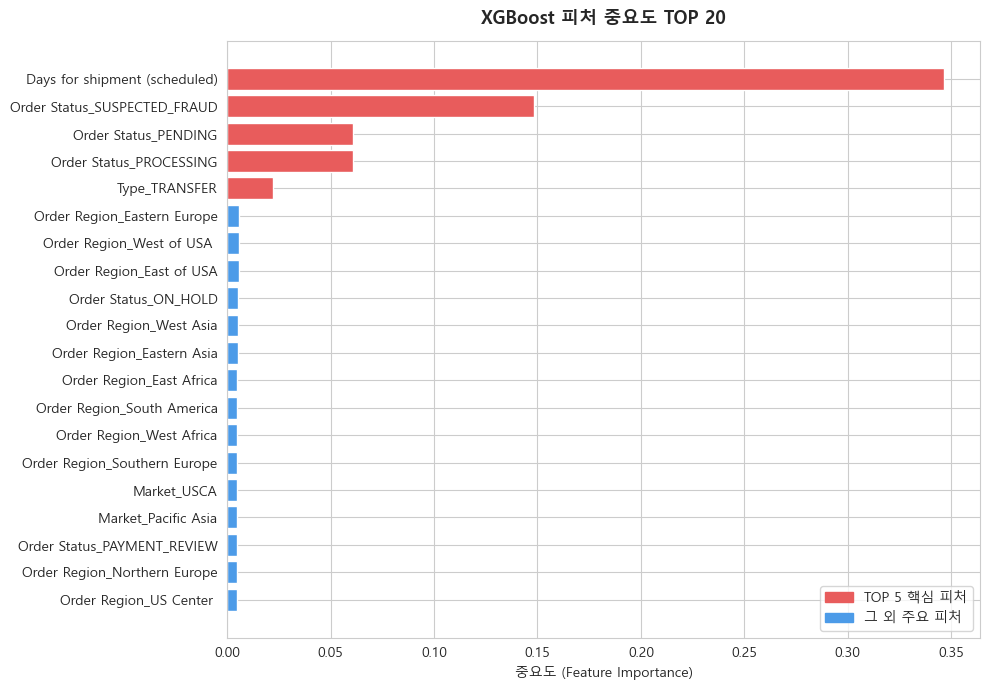

피처 중요도 TOP 10:
                           피처      중요도
Days for shipment (scheduled) 0.346680
 Order Status_SUSPECTED_FRAUD 0.148197
         Order Status_PENDING 0.060741
      Order Status_PROCESSING 0.060558
                Type_TRANSFER 0.021934
  Order Region_Eastern Europe 0.005760
    Order Region_West of USA  0.005418
     Order Region_East of USA 0.005404
         Order Status_ON_HOLD 0.005207
       Order Region_West Asia 0.004952


In [10]:
importance_df = pd.DataFrame({
    '피처': X.columns,
    '중요도': xgb_model.feature_importances_
}).sort_values('중요도', ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors = ['#E85C5C' if i < 5 else '#4C9BE8' for i in range(len(importance_df))]
plt.barh(importance_df['피처'][::-1], importance_df['중요도'][::-1], color=colors[::-1])
plt.title('XGBoost 피처 중요도 TOP 20', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('중요도 (Feature Importance)')

red_patch  = mpatches.Patch(color='#E85C5C', label='TOP 5 핵심 피처')
blue_patch = mpatches.Patch(color='#4C9BE8', label='그 외 주요 피처')
plt.legend(handles=[red_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.show()

print('피처 중요도 TOP 10:')
print(importance_df.head(10).to_string(index=False))

---
## 7. 리스크 스코어 산출

모델이 예측한 지연 확률(0~1)을 0~100점으로 변환해서 직관적인 리스크 스코어를 만든다.

| 스코어 | 위험 등급 | 의미 |
|--------|----------|------|
| 0 ~ 39  | 🟢 낮음 | 정상 배송 가능성 높음 |
| 40 ~ 69 | 🟡 보통 | 모니터링 필요 |
| 70 ~ 100 | 🔴 높음 | 사전 조치 필요 |

> 리스크 스코어는 모델의 예측 확률을 직관적으로 표현한 값이다. 실제 확률처럼 해석하려면 Calibration Curve, Brier Score 등 확률 보정 검증이 필요하다.

In [11]:
# 전체 데이터에 리스크 스코어 산출
all_proba = xgb_model.predict_proba(X)[:, 1]
df['risk_score'] = (all_proba * 100).round(1)

# 위험 등급 분류
def classify_risk(score):
    """리스크 스코어를 위험 등급으로 분류하는 함수"""
    if score < 40:
        return '낮음'
    elif score < 70:
        return '보통'
    else:
        return '높음'

df['risk_level'] = df['risk_score'].apply(classify_risk)

risk_dist = df['risk_level'].value_counts()
print('위험 등급별 주문 건수:')
for level in ['높음', '보통', '낮음']:
    count = risk_dist.get(level, 0)
    ratio = count / len(df) * 100
    print(f'  {level}: {count:,}건 ({ratio:.1f}%)')

위험 등급별 주문 건수:
  높음: 59,916건 (33.2%)
  보통: 55,708건 (30.9%)
  낮음: 64,895건 (35.9%)


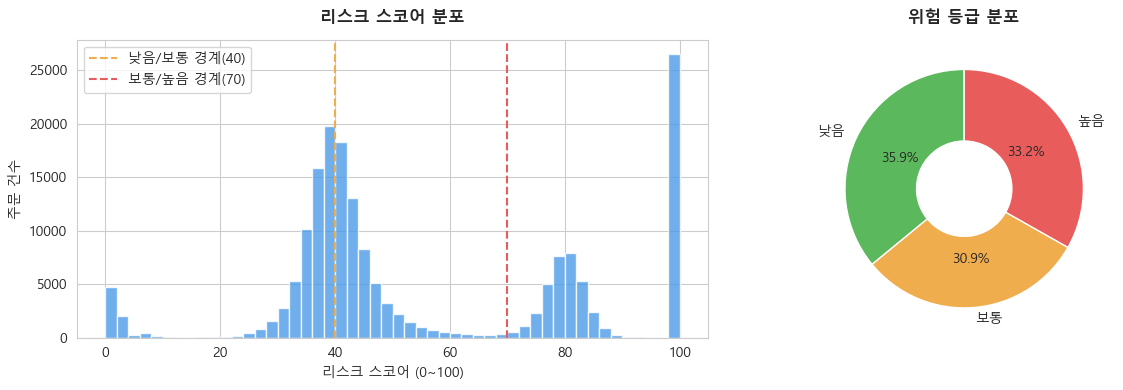

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 리스크 스코어 분포
axes[0].hist(df['risk_score'], bins=50, color='#4C9BE8', alpha=0.8, edgecolor='white')
axes[0].axvline(x=40, color='#F0AD4E', linestyle='--', linewidth=1.5, label='낮음/보통 경계(40)')
axes[0].axvline(x=70, color='#E85C5C', linestyle='--', linewidth=1.5, label='보통/높음 경계(70)')
axes[0].set_title('리스크 스코어 분포', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('리스크 스코어 (0~100)')
axes[0].set_ylabel('주문 건수')
axes[0].legend()

# 위험 등급 도넛 차트
level_order  = ['낮음', '보통', '높음']
level_counts = [risk_dist.get(l, 0) for l in level_order]
level_colors = ['#5CB85C', '#F0AD4E', '#E85C5C']
axes[1].pie(level_counts, labels=level_order, colors=level_colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title('위험 등급 분포', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

---
## 7-1. 리스크 스코어 운영 기준 검증

리스크 스코어를 실제 운영 기준으로 사용하려면, 단순히 AUC만 볼 것이 아니라 **고위험으로 분류한 주문군의 실제 지연율**을 확인해야 한다.

여기서는 테스트 데이터 기준으로 40점, 50점, 70점 이상을 각각 위험 주문으로 보고 Precision, Recall, F1, 실제 지연율을 비교한다.


In [13]:
threshold_rows = []
for threshold in [0.40, 0.50, 0.70]:
    pred_th = (xgb_proba >= threshold).astype(int)
    selected = pred_th == 1

    threshold_rows.append({
        '기준 점수': int(threshold * 100),
        '선별 주문 수': int(selected.sum()),
        'Precision': precision_score(y_test, pred_th),
        'Recall': recall_score(y_test, pred_th),
        'F1 Score': f1_score(y_test, pred_th),
        '선별 주문 실제 지연율': y_test[selected].mean() if selected.sum() > 0 else np.nan,
    })

threshold_df = pd.DataFrame(threshold_rows)
print('리스크 스코어 기준별 테스트 성능')
display(threshold_df.round(3))

high_risk_mask = xgb_proba >= 0.70
high_risk_actual_rate = y_test[high_risk_mask].mean()
overall_test_rate = y_test.mean()

print()
print(f'전체 테스트 데이터 지연율: {overall_test_rate*100:.1f}%')
print(f'70점 이상 고위험 주문 실제 지연율: {high_risk_actual_rate*100:.1f}%')
print('→ 70점 이상은 모든 지연 주문을 포착하기보다, 실제 지연 가능성이 높은 주문을 정밀하게 선별하는 기준으로 해석한다.')


리스크 스코어 기준별 테스트 성능


,기준 점수,선별 주문 수,Precision,Recall,F1 Score,선별 주문 실제 지연율
0,40,23127,0.678,0.792,0.730,0.678
1,50,13363,0.860,0.580,0.693,0.860
2,70,12048,0.890,0.542,0.674,0.890



전체 테스트 데이터 지연율: 54.8%
70점 이상 고위험 주문 실제 지연율: 89.0%
→ 70점 이상은 모든 지연 주문을 포착하기보다, 실제 지연 가능성이 높은 주문을 정밀하게 선별하는 기준으로 해석한다.


---
## 7-2. 확률 보정 점검

리스크 스코어는 `predict_proba`를 0~100점으로 변환한 값이다.  
따라서 예측 확률 구간별 실제 지연율을 비교해, 모델 확률이 실제 지연율과 어느 정도 맞는지 점검한다.


Brier Score: 0.1767


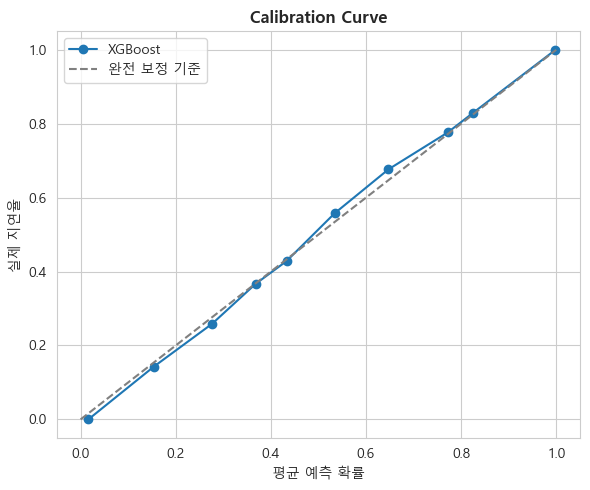

해석: 곡선이 대각선에 가까울수록 예측 확률이 실제 지연율과 잘 맞는다.
현재 모델은 고위험 주문 선별에는 활용 가능하지만, 운영 적용 전 확률 보정 개선 여지가 있다.


In [14]:
# Brier Score: 확률 예측 품질을 보는 지표. 낮을수록 좋음.
brier = brier_score_loss(y_test, xgb_proba)
print(f'Brier Score: {brier:.4f}')

prob_true, prob_pred = calibration_curve(y_test, xgb_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='완전 보정 기준')
plt.xlabel('평균 예측 확률')
plt.ylabel('실제 지연율')
plt.title('Calibration Curve', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('해석: 곡선이 대각선에 가까울수록 예측 확률이 실제 지연율과 잘 맞는다.')
print('현재 모델은 고위험 주문 선별에는 활용 가능하지만, 운영 적용 전 확률 보정 개선 여지가 있다.')


---
## 8. 고위험 주문 세그멘테이션

리스크 스코어가 높은 주문들의 특성을 파악해서 실무 인사이트를 도출한다.

In [15]:
# 원본 데이터에 리스크 스코어 합치기 (범주형 값 그대로 보기 위해)
raw_candidates = [
    Path('../data/raw/DataCoSupplyChainDataset.csv'),
    Path('data/raw/DataCoSupplyChainDataset.csv'),
    Path('DataCoSupplyChainDataset.csv'),
    Path('/mnt/data/DataCoSupplyChainDataset.csv'),
]

for path in raw_candidates:
    if path.exists():
        raw_path = path
        break
else:
    raise FileNotFoundError('DataCoSupplyChainDataset.csv 원본 파일을 찾을 수 없습니다.')

df_raw = pd.read_csv(raw_path, encoding='latin1')
df_raw['risk_score'] = df['risk_score'].values
df_raw['risk_level'] = df['risk_level'].values

high_risk = df_raw[df_raw['risk_level'] == '높음']
low_risk  = df_raw[df_raw['risk_level'] == '낮음']

print(f'원본 데이터 경로: {raw_path}')
print(f'고위험 주문: {len(high_risk):,}건')
print(f'저위험 주문: {len(low_risk):,}건')


원본 데이터 경로: ..\data\raw\DataCoSupplyChainDataset.csv
고위험 주문: 59,916건
저위험 주문: 64,895건


### 실제 지연율과 모델 고위험 비율 구분

배송 방식별 **실제 지연율**과 모델이 산출한 **고위험 비율**은 같은 지표가 아니다.  
실제 지연율은 관측된 결과이고, 고위험 비율은 모델이 70점 이상으로 분류한 비율이다.


In [16]:
actual_delay_by_ship = df_raw.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
model_high_by_ship = df_raw.groupby('Shipping Mode')['risk_level'].apply(lambda x: (x == '높음').mean()).sort_values(ascending=False) * 100

ship_compare = pd.DataFrame({
    '실제 지연율(%)': actual_delay_by_ship.round(1),
    '모델 고위험 비율(%)': model_high_by_ship.round(1),
})

print('배송 방식별 실제 지연율 vs 모델 고위험 비율')
display(ship_compare)
print('해석: Standard Class는 주문 수가 많지만 실제 지연율은 상대적으로 낮다. 고위험 관리는 First/Second Class 중심으로 우선 점검한다.')


배송 방식별 실제 지연율 vs 모델 고위험 비율


,실제 지연율(%),모델 고위험 비율(%)
Shipping Mode,,
First Class,95.3,95.3
Second Class,76.6,94.1
Same Day,45.7,2.6
Standard Class,38.1,0.0


해석: Standard Class는 주문 수가 많지만 실제 지연율은 상대적으로 낮다. 고위험 관리는 First/Second Class 중심으로 우선 점검한다.


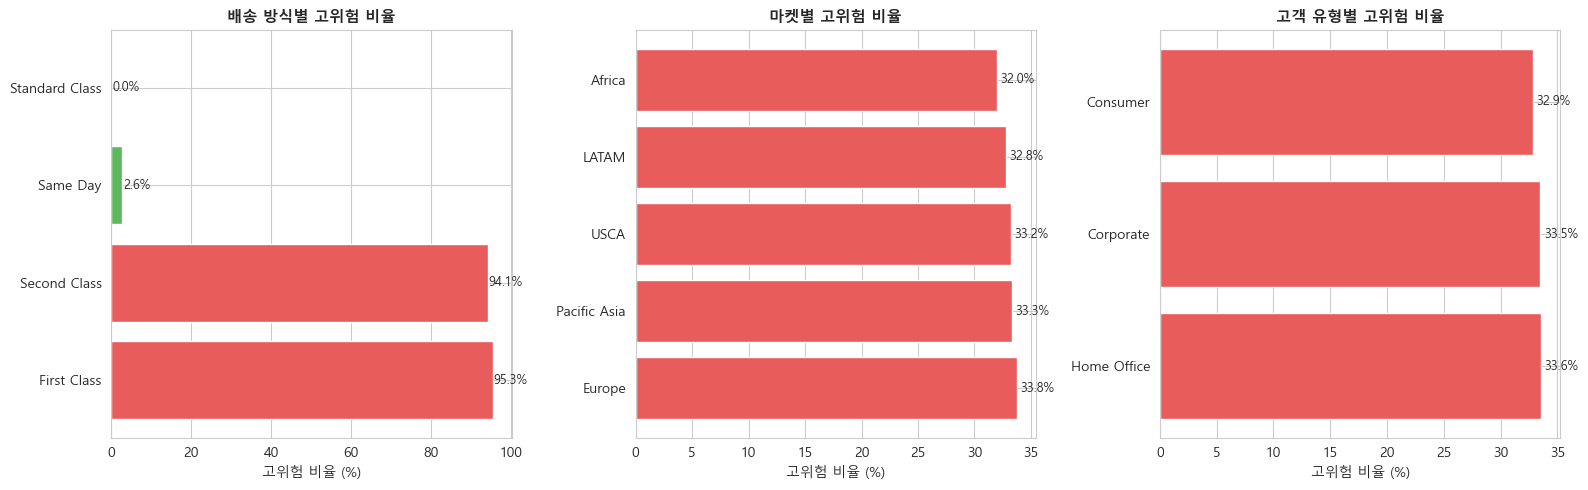

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 배송 방식별 고위험 비율
ship_risk = df_raw.groupby('Shipping Mode')['risk_level'].apply(
    lambda x: (x == '높음').sum() / len(x) * 100
).sort_values(ascending=False)
bar_c = ['#E85C5C' if v > 30 else '#F0AD4E' if v > 15 else '#5CB85C' for v in ship_risk.values]
axes[0].barh(ship_risk.index, ship_risk.values, color=bar_c)
axes[0].set_title('배송 방식별 고위험 비율', fontsize=11, fontweight='bold')
axes[0].set_xlabel('고위험 비율 (%)')
for i, v in enumerate(ship_risk.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# 마켓별 고위험 비율
market_risk = df_raw.groupby('Market')['risk_level'].apply(
    lambda x: (x == '높음').sum() / len(x) * 100
).sort_values(ascending=False)
bar_c2 = ['#E85C5C' if v > 30 else '#F0AD4E' if v > 15 else '#5CB85C' for v in market_risk.values]
axes[1].barh(market_risk.index, market_risk.values, color=bar_c2)
axes[1].set_title('마켓별 고위험 비율', fontsize=11, fontweight='bold')
axes[1].set_xlabel('고위험 비율 (%)')
for i, v in enumerate(market_risk.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# 고객 유형별 고위험 비율
seg_risk = df_raw.groupby('Customer Segment')['risk_level'].apply(
    lambda x: (x == '높음').sum() / len(x) * 100
).sort_values(ascending=False)
bar_c3 = ['#E85C5C' if v > 30 else '#F0AD4E' if v > 15 else '#5CB85C' for v in seg_risk.values]
axes[2].barh(seg_risk.index, seg_risk.values, color=bar_c3)
axes[2].set_title('고객 유형별 고위험 비율', fontsize=11, fontweight='bold')
axes[2].set_xlabel('고위험 비율 (%)')
for i, v in enumerate(seg_risk.values):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# 고위험 vs 저위험 그룹 주요 수치 비교
compare_cols = [
    'Days for shipment (scheduled)',
    'Sales',
    'Order Item Quantity',
    'Order Profit Per Order',
    'Order Item Discount Rate'
]

compare_df = pd.DataFrame({
    '고위험 평균': high_risk[compare_cols].mean(),
    '저위험 평균': low_risk[compare_cols].mean(),
}).round(2)
compare_df['차이'] = (compare_df['고위험 평균'] - compare_df['저위험 평균']).round(2)

print('=== 고위험 vs 저위험 그룹 비교 ===')
print(compare_df)

=== 고위험 vs 저위험 그룹 비교 ===
                               고위험 평균  저위험 평균    차이
Days for shipment (scheduled)    1.55    3.75 -2.20
Sales                          203.17  204.45 -1.28
Order Item Quantity              2.13    2.13  0.00
Order Profit Per Order          22.03   22.84 -0.81
Order Item Discount Rate         0.10    0.10  0.00


---
## 9. 최종 인사이트 정리

In [19]:
print('='*60)
print('              최종 분석 인사이트')
print('='*60)
print()

print('[모델 성능 요약]')
print(f'  XGBoost  Accuracy {xgb_acc*100:.1f}%  F1 {xgb_f1:.3f}  ROC-AUC {xgb_auc:.3f}')
print('  주문 시점 정보만으로 AUC 약 0.79 달성')
print('  → 완전 자동 의사결정보다는 고위험 주문 우선 점검 도구로 활용 가능')
print()

print('[핵심 발견 1] 예정 배송 소요일이 지연 예측의 핵심 변수')
print('  Days for shipment (scheduled)는 주문 시점에 확인 가능한 변수이며,')
print('  예정 배송일이 짧은 주문일수록 지연 위험이 높게 나타남')
print('  Days for shipping (real)은 배송 완료 후 정보이므로 모델 피처에서 제거함')
print()

print('[핵심 발견 2] First Class / Second Class에서 실제 지연율이 높음')
print('  빠른 배송을 약속한 주문일수록 운영 여유가 적어 지연 위험이 커질 수 있음')
print('  Standard Class는 주문 수가 많아 운영상 중요하지만, 실제 지연율 자체가 가장 높은 배송 방식은 아님')
print('  → 배송 방식별 실제 지연율과 모델 고위험 비율을 구분해 해석 필요')
print()

print('[핵심 발견 3] 리스크 스코어로 사전 대응 우선순위 설정 가능')
print(f'  테스트 데이터 기준 70점 이상 주문 실제 지연율: {high_risk_actual_rate*100:.1f}%')
print(f'  전체 테스트 데이터 지연율: {overall_test_rate*100:.1f}%')
print('  → 출고 우선순위, 예상 배송일, 사전 안내 여부를 점검하는 기준으로 활용 가능')
print()

print('[한계점 및 개선 방향]')
print('  - Order Status 변수는 일부 주문 상태에서 별도 운영 리스크와 혼재될 수 있음')
print('  - 확률값을 리스크 스코어로 활용하기 위해 향후 Calibration 보정 필요')
print('  - 날씨, 공휴일, 물류센터 처리량 등 외부 데이터 결합 시 성능 개선 가능')
print('  - 실제 운영 적용 전 세그먼트별 모델 검증 필요')
print('='*60)

              최종 분석 인사이트

[모델 성능 요약]
  XGBoost  Accuracy 71.8%  F1 0.693  ROC-AUC 0.790
  주문 시점 정보만으로 AUC 약 0.79 달성
  → 완전 자동 의사결정보다는 고위험 주문 우선 점검 도구로 활용 가능

[핵심 발견 1] 예정 배송 소요일이 지연 예측의 핵심 변수
  Days for shipment (scheduled)는 주문 시점에 확인 가능한 변수이며,
  예정 배송일이 짧은 주문일수록 지연 위험이 높게 나타남
  Days for shipping (real)은 배송 완료 후 정보이므로 모델 피처에서 제거함

[핵심 발견 2] First Class / Second Class에서 실제 지연율이 높음
  빠른 배송을 약속한 주문일수록 운영 여유가 적어 지연 위험이 커질 수 있음
  Standard Class는 주문 수가 많아 운영상 중요하지만, 실제 지연율 자체가 가장 높은 배송 방식은 아님
  → 배송 방식별 실제 지연율과 모델 고위험 비율을 구분해 해석 필요

[핵심 발견 3] 리스크 스코어로 사전 대응 우선순위 설정 가능
  테스트 데이터 기준 70점 이상 주문 실제 지연율: 89.0%
  전체 테스트 데이터 지연율: 54.8%
  → 출고 우선순위, 예상 배송일, 사전 안내 여부를 점검하는 기준으로 활용 가능

[한계점 및 개선 방향]
  - Order Status 변수는 일부 주문 상태에서 별도 운영 리스크와 혼재될 수 있음
  - 확률값을 리스크 스코어로 활용하기 위해 향후 Calibration 보정 필요
  - 날씨, 공휴일, 물류센터 처리량 등 외부 데이터 결합 시 성능 개선 가능
  - 실제 운영 적용 전 세그먼트별 모델 검증 필요


In [20]:
import os

os.makedirs('../data/processed', exist_ok=True)
result_path = '../data/processed/data_with_risk_score.csv'
df_raw.to_csv(result_path, index=False)

print(f'리스크 스코어 포함 최종 데이터 저장 완료')
print(f'저장 위치: {result_path}')
print(f'크기: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}컬럼')

리스크 스코어 포함 최종 데이터 저장 완료
저장 위치: ../data/processed/data_with_risk_score.csv
크기: 180,519행 × 55컬럼


---
## 10. 대시보드용 모델 파일 저장

Streamlit 대시보드에서 매번 모델을 새로 학습하면 시간이 오래 걸린다.  
학습된 모델과 피처 컬럼 목록을 파일로 저장해두면 대시보드가 빠르게 불러올 수 있다.

> 이 셀은 `dashboard/app.py` 를 실행하기 전에 반드시 실행해야 한다.

In [21]:
import pickle
import os

# dashboard 폴더 생성 (없으면)
os.makedirs('../dashboard', exist_ok=True)

# 학습된 XGBoost 모델 저장
with open('../dashboard/model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# 피처 컬럼 목록 저장 — 대시보드에서 입력값을 같은 순서로 맞추기 위해 필요
with open('../dashboard/feature_cols.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print('대시보드용 파일 저장 완료')
print('  - dashboard/model.pkl        : 학습된 XGBoost 모델')
print('  - dashboard/feature_cols.pkl : 피처 컬럼 목록')
print()
print('이제 아래 명령어로 대시보드를 실행할 수 있습니다.')
print('  streamlit run dashboard/app.py')

대시보드용 파일 저장 완료
  - dashboard/model.pkl        : 학습된 XGBoost 모델
  - dashboard/feature_cols.pkl : 피처 컬럼 목록

이제 아래 명령어로 대시보드를 실행할 수 있습니다.
  streamlit run dashboard/app.py
